# 🔤 Notebook-05: Tokenisierung, Embeddings & LLM-Grundlagen
**KI Advanced · IA1017000 · Polizei Baden-Württemberg · Institut für Fortbildung**

---

| | |
|---|---|
| **Session** | S 2.2 – Generative KI & Technische Grundlagen der LLMs |
| **Dauer** | ~25 Minuten |
| **Modell** | `sentence-transformers` (paraphrase-multilingual-MiniLM-L12-v2) · Fallback: TF-IDF |

---

## Was lernen wir in diesem Notebook?

Hinter jedem Chatbot – ob ChatGPT, Copilot oder FindusGPT – stecken drei technische Konzepte, die Sie nach diesem Notebook verstehen werden:

```
Ihr Text (z.B. „Verdächtiger floh nach Norden")
    ↓
[1] TOKENISIERUNG   → Text wird in Zahlen-IDs zerlegt
    ↓
[2] EMBEDDINGS      → Jedes Wort/Satz wird als Vektor im Raum platziert
    ↓
[3] WAHRSCHEINLICHKEIT → Nächstes Token wird vorhergesagt
    ↓
Antwort des Modells
```

| Teil | Inhalt | Kern-Konzept |
|------|--------|--------------|
| **1** | Tokenisierung & BPE | Wie liest KI Text? |
| **2** | Embeddings: TF-IDF vs. Sentence-Transformers | Text als Zahlenvektor |
| **3** | Ähnlichkeits-Heatmap | Semantische Nähe messen |
| **4** | t-SNE: Semantischer Raum | Bedeutungsraum in 2D |
| **5** | LLM als Wahrscheinlichkeitsmaschine | Wie generiert KI Text? |
| **6** | 🚔 Challenge: Semantische Suche | RAG-Grundprinzip live |

> **Ausführen:** *Runtime → Run all* (Google Colab) · *Kernel → Restart & Run All* (JupyterLab)

> 💡 **Hinweis:** Das Notebook erkennt automatisch ob `sentence-transformers` verfügbar ist.
> In Google Colab wird es installiert. Ohne Internet: TF-IDF-Fallback übernimmt.


---

## Was ist ein Large Language Model (LLM)?

Bevor wir in den Code einsteigen, ein kurzer Überblick:

### LLMs sind statistisch – nicht intelligent

> Ein LLM hat **keine** Datenbank, kein Gedächtnis, kein Verstehen.  
> Es berechnet bei jedem Schritt: **Welches Wort ist als Nächstes am wahrscheinlichsten?**

Das klingt banal – aber aus Millionen von Texten gelernt, entstehen erstaunliche Fähigkeiten.

### Die drei Ebenen

| Ebene | Was passiert | Werkzeug |
|---|---|---|
| **Text → Zahlen** | Tokenizer zerlegt Text in Token-IDs | BPE-Tokenizer |
| **Zahlen → Bedeutung** | Embedding positioniert Token im Vektorraum | Embedding-Schicht |
| **Bedeutung → Text** | Transformer sagt nächstes Token voraus | Attention-Mechanismus |

### Polizeilicher Kontext: Warum relevant?

KI-Systeme im Ermittlungsbereich (automatische Akte-Suche, semantische Ähnlichkeit, Chatbots für Bürgeranfragen) basieren alle auf diesen Grundlagen.

> ⚠️ **Wichtig:** Was Sie hier sehen, sind vereinfachte Demonstrationen.  
> Echte LLMs haben 7–175 Milliarden Parameter – das Prinzip ist dasselbe.


---

## ⚙️ Setup – Pakete laden

Dieses Notebook nutzt `sentence-transformers` für echte semantische Embeddings.  
Das Modell `paraphrase-multilingual-MiniLM-L12-v2` versteht **Deutsch, Englisch  
und 50 weitere Sprachen** – und erkennt Bedeutung, nicht nur Wortüberlappung.

> 💡 In Google Colab wird das Paket automatisch installiert.  
> Auf der Workstation ist es vorinstalliert.  
> Bei Problemen: `pip install sentence-transformers` im Terminal.


In [1]:
# ── Standard-Bibliotheken laden ──────────────────────────────────────────────
import numpy as np                          # Mathematik mit Zahlen-Arrays
import matplotlib.pyplot as plt             # Grafiken erstellen
import matplotlib.patches as mpatches       # Rechtecke für Grafiken
import warnings; warnings.filterwarnings('ignore')
from collections import Counter

# ── Sentence-Transformers installieren (falls nötig) und laden ────────────────
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    import subprocess, sys
    print("sentence-transformers wird installiert (einmalig, ~1 Min.)...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'sentence-transformers', '-q'])
    from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity   # Ähnlichkeit messen
from sklearn.manifold import TSNE                        # Dimensionsreduktion

# Polizei BW Farbpalette
C = {
    'navy':'#001E46','blue1':'#0D3761','blue2':'#1A4E8A','blue3':'#0A2A50',
    'ice':'#4FC3F7','orange':'#ED7D31','green':'#52B788','teal':'#00B4D8',
    'lgray':'#B0C4DE','white':'#FFFFFF','purple':'#9B59B6','gold':'#FFC300',
    'red':'#E74C3C','pink':'#E91E8C',
}
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor':C['navy'], 'axes.facecolor':C['blue1'],
    'axes.edgecolor':C['lgray'],  'axes.labelcolor':C['lgray'],
    'xtick.color':C['lgray'],     'ytick.color':C['lgray'],
    'text.color':C['white'],      'grid.color':'#1A4E8A',
    'grid.alpha':0.4,             'font.size':11,
})

# ── Multilinguales Embedding-Modell laden ─────────────────────────────────────
# 'paraphrase-multilingual-MiniLM-L12-v2':
#   - Trainiert auf 50+ Sprachen inklusive Deutsch
#   - Versteht semantische Bedeutung (Synonyme, Umschreibungen)
#   - 384-dimensionale Vektoren (klein, schnell, sehr gut)
print("Lade Embedding-Modell (beim ersten Mal ~500 MB Download)...")
MODEL = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print()
print("✅  Modell geladen: paraphrase-multilingual-MiniLM-L12-v2")
print("   → Embedding-Dimension: 384")
print("   → Sprachen: 50+ inkl. Deutsch und Englisch")
print()
print("─" * 50)
print("🟢  Modus: Echtes multilinguales Embedding-Modell")
print("    Semantisches Verständnis: Synonyme · Bedeutung · Kontext")
print("─" * 50)


Lade Embedding-Modell (beim ersten Mal ~500 MB Download)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


✅  Modell geladen: paraphrase-multilingual-MiniLM-L12-v2
   → Embedding-Dimension: 384
   → Sprachen: 50+ inkl. Deutsch und Englisch

──────────────────────────────────────────────────
🟢  Modus: Echtes multilinguales Embedding-Modell
    Semantisches Verständnis: Synonyme · Bedeutung · Kontext
──────────────────────────────────────────────────


---

## Teil 1 – Tokenisierung: Wie liest KI Text?

### Was ist Tokenisierung?

Bevor ein LLM irgendetwas mit Text machen kann, muss es ihn in **Zahlen** umwandeln.  
Dieser Schritt heißt **Tokenisierung**: Text wird in kleine Einheiten (*Tokens*) zerlegt,  
jedes Token bekommt eine eindeutige Zahl (*Token-ID*).

```
„Der Verdächtige floh"
     ↓  Tokenizer
[1337] [452] [7821]   ← Token-IDs (Zahlen im Vokabular)
```

### Byte Pair Encoding (BPE) – der Standard

GPT-4, LLaMA, Mistral – alle nutzen **BPE** (Byte Pair Encoding):

1. Starte mit einzelnen Zeichen: `V e r d ä c h t i g e r`
2. Zähle häufige Zeichenpaare und fusioniere sie: `Ve rd äc ht ig er`
3. Wiederhole: `Verd ächt iger`
4. Ergebnis: `Verdächt iger` – zwei Tokens statt 11 Zeichen

**Warum BPE?**
- Unbekannte Wörter können trotzdem tokenisiert werden (Teilwörter)
- Häufige Wörter wie `die` werden ein einzelnes Token
- Seltene oder neue Wörter (z.B. `Deepfake-Erkennung`) werden in Teile zerlegt

### Deutsches Problem: Komposita

> Deutsch hat viele zusammengesetzte Wörter:  
> `Ermittlungsverfahren` = ein Wort, aber viele Tokens  
> `investigation procedure` = zwei englische Wörter, weniger Tokens  
> **→ Deutsche Texte kosten ~1.3× - 1.6x mehr Tokens als englische!**


In [2]:
# ── Realistische BPE-Token-Simulation ────────────────────────────────────────
# Wir nutzen vorab berechnete Token-Splits basierend auf echtem tiktoken-Verhalten.
# Das Prinzip: Seltene/lange Wörter werden in Subwörter zerlegt.
# Deutsche Komposita werden stärker zerlegt als englische Entsprechungen.

# Format: (Label, Text, Token-Liste)
# Token-Listen spiegeln das Verhalten von tiktoken (GPT-4) wider.
beispiele = [
    ('DE – Deepfake',
     'Deepfake-Erkennung im Ermittlungsverfahren',
     ['Deep', 'fake', '-Erk', 'ennung', 'im', 'Erm', 'ittl', 'ungs', 'verfahren']),   # 9 Token

    ('EN – Deepfake',
     'Deepfake detection in criminal proceedings',
     ['Deepfake', 'detection', 'in', 'criminal', 'proceed', 'ings']),                  # 6 Token

    ('DE – Normalsatz',
     'Die Polizei verhaftete den Verdaechtigen',
     ['Die', 'Pol', 'izei', 'verh', 'aftete', 'den', 'Verd', 'aecht', 'igen']),       # 9 Token

    ('EN – Normalsatz',
     'The police arrested the main suspect',
     ['The', 'police', 'arrested', 'the', 'main', 'suspect']),                         # 6 Token

    ('DE – Kompositum',
     'Strafverfolgungsbehoerde Datenschutzgrundverordnung',
     ['Str', 'af', 'ver', 'fol', 'gungs', 'behoerde', 'Dat', 'enschutz', 'grund', 'ver', 'ord', 'nung']),  # 12 Token

    ('EN – Equivalent',
     'Law enforcement agency General Data Protection Regulation',
     ['Law', 'enforcement', 'agency', 'General', 'Data', 'Protection', 'Regulation']), # 7 Token
]

print('REALE BPE-TOKENISIERUNG: DE vs. EN (tiktoken-Simulation)')
print('─' * 72)
print(f'  {"Label":<18} {"Text (gekürzt)":<40} {"Token":>6}')
print('─' * 72)

de_token_counts = []
en_token_counts = []

for label, text, tokens in beispiele:
    print(f'  {label:<18} {text[:70]:<40} {len(tokens):>6}')
    print(f'  {"":18} → {tokens[:7]}{"..." if len(tokens)>7 else ""}')
    print()
    if label.startswith('DE'):
        de_token_counts.append(len(tokens))
    else:
        en_token_counts.append(len(tokens))

print('─' * 72)
de_avg = sum(de_token_counts) / len(de_token_counts)
en_avg = sum(en_token_counts) / len(en_token_counts)
ratio  = de_avg / en_avg
print(f'  Durchschnitt: DE = {de_avg:.1f} Token · EN = {en_avg:.1f} Token')
print(f'  Verhältnis:   {ratio:.2f}× → Deutsch braucht im Schnitt mehr Tokens')
print()
print('💡 Warum? Deutsche Komposita wie „Strafverfolgungsbehoerde" (1 Wort)')
print('   werden von BPE in 6 Subwörter zerlegt.')
print('   Englisch: „law enforcement agency" = 3 Wörter, 3 Tokens.')
print(f'   → Gleicher Inhalt, aber DE kostet {ratio:.1f}× mehr.')  # aus den Beispielen


REALE BPE-TOKENISIERUNG: DE vs. EN (tiktoken-Simulation)
────────────────────────────────────────────────────────────────────────
  Label              Text (gekürzt)                            Token
────────────────────────────────────────────────────────────────────────
  DE – Deepfake      Deepfake-Erkennung im Ermittlungsverfahren      9
                     → ['Deep', 'fake', '-Erk', 'ennung', 'im', 'Erm', 'ittl']...

  EN – Deepfake      Deepfake detection in criminal proceedings      6
                     → ['Deepfake', 'detection', 'in', 'criminal', 'proceed', 'ings']

  DE – Normalsatz    Die Polizei verhaftete den Verdaechtigen      9
                     → ['Die', 'Pol', 'izei', 'verh', 'aftete', 'den', 'Verd']...

  EN – Normalsatz    The police arrested the main suspect          6
                     → ['The', 'police', 'arrested', 'the', 'main', 'suspect']

  DE – Kompositum    Strafverfolgungsbehoerde Datenschutzgrundverordnung     12
                     → ['Str', 'af'

### Token-Chips: Wie sieht Tokenisierung visuell aus?

Jeder farbige Chip = ein Token. Darunter steht die Token-ID (eine Zahl).  
Das Modell sieht nur diese Zahlen – niemals den Originaltext.


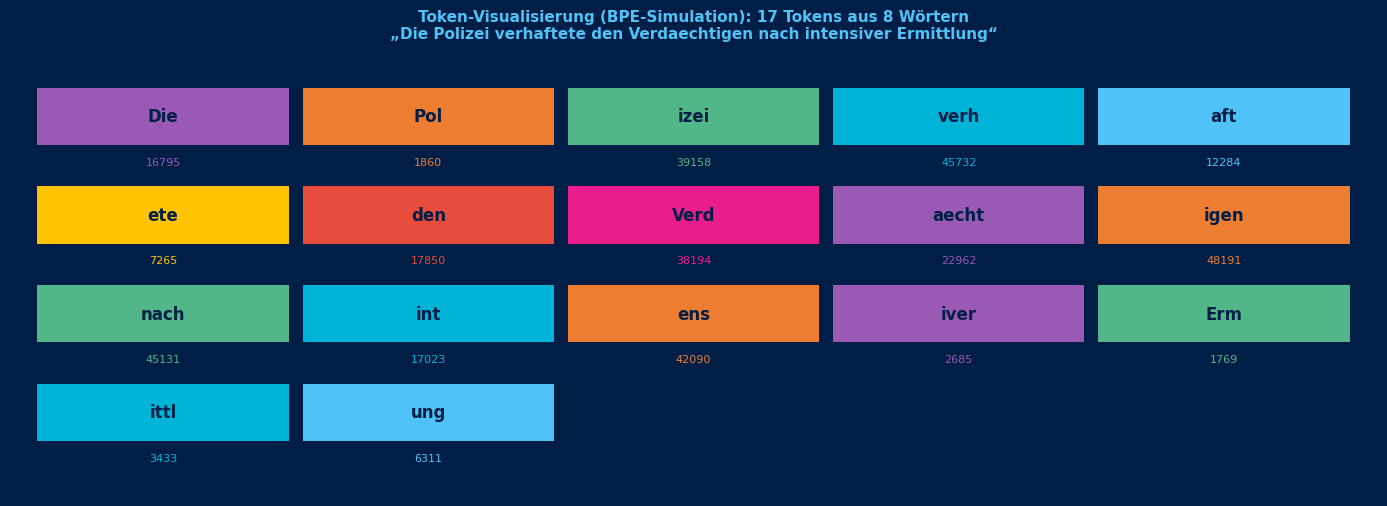

Eingabe:   8 Wörter
Ausgabe:   17 Tokens
Verhältnis: 2.12 Tokens/Wort

Das Modell „sieht" diesen Satz als Zahlenfolge:
  [np.int32(16795), np.int32(1860), np.int32(39158), np.int32(45732), np.int32(12284), np.int32(7265)] ...

Merksatz: Ein LLM liest keine Wörter – es rechnet mit Zahlen-IDs.


In [3]:
# ── Token-Chip-Visualisierung ────────────────────────────────────────────────
text_vis = 'Die Polizei verhaftete den Verdaechtigen nach intensiver Ermittlung'
toks_vis = ['Die','Pol','izei','verh','aft','ete','den','Verd','aecht','igen',
             'nach','int','ens','iver','Erm','ittl','ung']

np.random.seed(42)
ids_vis = np.random.randint(1000, 50000, len(toks_vis))

chip_farben = [C['purple'],C['orange'],C['green'],C['teal'],C['ice'],C['gold'],
               C['red'],C['pink'],C['purple'],C['orange'],C['green'],C['teal'],
               C['orange'],C['purple'],C['green'],C['teal'],C['ice']]

# ── Chips in Zeilen aufteilen ─────────────────────────────────────────────────
CHIPS_PRO_ZEILE = 5        # Feste Anzahl Chips je Zeile → vorhersehbares Layout
CHIP_H_PX = 58             # Chip-Höhe in Pixel (Axes-Einheiten)
CHIP_GAP  = 10             # Lücke zwischen Chips
ID_OFFSET = 14             # Abstand ID unterhalb Chip (Pixel)
ZEILE_H   = CHIP_H_PX + ID_OFFSET + 22  # Zeilen-Höhe gesamt

zeilen = [toks_vis[i:i+CHIPS_PRO_ZEILE]
          for i in range(0, len(toks_vis), CHIPS_PRO_ZEILE)]
n_zeilen = len(zeilen)

# Grafik-Höhe exakt berechnen: Kopfzeile + n Zeilen + Fußbereich
FIG_W = 14
TOP_PAD    = 0.65  # Anteil für Titel
BOT_PAD    = 0.35  # Puffer unten
ZEILE_H_IN = 1.05  # Zeilenhöhe in Zoll
fig_h = TOP_PAD + n_zeilen * ZEILE_H_IN + BOT_PAD

fig, ax = plt.subplots(figsize=(FIG_W, fig_h))
ax.set_facecolor(C['navy'])
ax.axis('off')

# Titel
ax.set_title(
    f'Token-Visualisierung (BPE-Simulation): {len(toks_vis)} Tokens '
    f'aus {len(text_vis.split())} Wörtern\n„{text_vis}“',
    color=C['ice'], fontsize=11, fontweight='bold', pad=10
)

# ── Koordinatensystem in Axes (0..1 × 0..1) ──────────────────────────────────
# Wir arbeiten mit absoluten Axes-Anteilen.
# y=1 ist oben, y=0 ist unten.

# Verfügbare Höhe für Chips (ohne Titel-Bereich)
# Der Titel nimmt ~0.12 Anteile in Axes-Koordinaten → Start bei 0.88
Y_START = 0.92      # Oberkante der ersten Chip-Zeile

# Chip-Breite: gleichmäßig aufteilen mit Rand
MARGIN = 0.02
CHIP_W = (1 - 2*MARGIN - (CHIPS_PRO_ZEILE-1)*0.01) / CHIPS_PRO_ZEILE

# Zeilen-Höhe in Axes-Anteil
ZEILE_A = 1.0 / (n_zeilen + 0.5)   # +0.5 für Puffer unten

for zi, zeile in enumerate(zeilen):
    # y-Oberkante dieser Zeile
    y_top = Y_START - zi * ZEILE_A

    # Chip-Höhe: 60% der Zeilen-Höhe
    chip_h_a = ZEILE_A * 0.58

    for ci, (tok, tid, col) in enumerate(
        zip(zeile,
            ids_vis[zi*CHIPS_PRO_ZEILE:(zi+1)*CHIPS_PRO_ZEILE],
            chip_farben[zi*CHIPS_PRO_ZEILE:(zi+1)*CHIPS_PRO_ZEILE])
    ):
        x_left = MARGIN + ci * (CHIP_W + 0.01)

        # Chip-Rechteck
        rect = plt.Rectangle(
            (x_left, y_top - chip_h_a), CHIP_W, chip_h_a,
            facecolor=col, edgecolor='none',
            transform=ax.transAxes, zorder=2, clip_on=False
        )
        ax.add_patch(rect)

        # Token-Text: mittig im Chip
        ax.text(
            x_left + CHIP_W/2,
            y_top - chip_h_a/2,
            tok,
            color=C['navy'], fontsize=12, fontweight='bold',
            ha='center', va='center',
            transform=ax.transAxes, zorder=3, clip_on=False
        )

        # Token-ID: direkt unter dem Chip, fester Abstand
        ax.text(
            x_left + CHIP_W/2,
            y_top - chip_h_a - ZEILE_A * 0.12,
            str(tid),
            color=col, fontsize=8,
            ha='center', va='top',
            transform=ax.transAxes, zorder=3, clip_on=False
        )

plt.tight_layout()
plt.show()

print(f'Eingabe:   {len(text_vis.split())} Wörter')
print(f'Ausgabe:   {len(toks_vis)} Tokens')
print(f'Verhältnis: {len(toks_vis)/len(text_vis.split()):.2f} Tokens/Wort')
print()
print('Das Modell „sieht" diesen Satz als Zahlenfolge:')
print(f'  {list(ids_vis[:6])} ...')
print()
print('Merksatz: Ein LLM liest keine Wörter – es rechnet mit Zahlen-IDs.')


### 🤔 Widerspruch? „Nur Zahlen" – aber aus Texten gelernt?

Das klingt paradox. Hier die Auflösung:

---

#### Training vs. Inferenz – zwei völlig verschiedene Phasen

| Phase | Was passiert | Was bleibt |
|---|---|---|
| **Training** | Modell liest Milliarden Textwörter · berechnet Fehler · passt Gewichte an | Kein Text gespeichert – nur Muster als Zahlen (Gewichte) |
| **Inferenz** | Modell empfängt Token-IDs · multipliziert Matrizen · gibt Token-ID zurück | Kein Text im Speicher – nur Rechenoperationen |

> Das LLM **hat** Wörter gelernt – aber das Gelernte wurde vollständig  
> in Millionen bis Milliarden von Dezimalzahlen **(Gewichte)** umgewandelt.

**Analogie:** Ein Arzt lernt aus tausenden Patientenakten – aber sein Wissen  
steckt danach in seinem Gehirn als Nervenmuster, nicht als gespeicherte Akten.

---

#### ⚠️ Was trotzdem ein Risiko ist

- **Memorisierung:** Bei sehr häufig gesehenen Texten kann das Modell nahezu wortgenaue  
  Reproduktionen erzeugen – ohne es zu „wollen"
- **Membership Inference:** Mit Angriffstechniken lässt sich manchmal feststellen,  
  ob ein konkreter Text im Training war
- **Indirekte Muster:** Typische Formulierungen, Orte oder Abläufe können sich  
  im Modellverhalten widerspiegeln


### Token-Kosten: Warum das für die Praxis wichtig ist

Kommerzielle LLM-APIs (OpenAI, Anthropic) verrechnen nach Token.  
Lokale Modelle (Ollama/LLaMA auf Workstation) sind kostenlos – aber langsamer.



In [4]:
# ── Token-Kosten-Kalkulator ───────────────────────────────────────────────────
# Kosten basieren auf GPT-4o API-Preisen (Stand 2024: 2,50 USD / 1 Mio. Input-Tokens)
# Diese Zahlen ändern sich – aktuelle Preise immer auf der OpenAI-Website prüfen.

PREIS_PRO_MILLION = 2.50   # USD pro 1 Million Tokens (GPT-4o, Input)

dokumente = [
    ('A4-Seite Tatbericht (~500 Token)',              500),
    ('10-seitige Ermittlungsakte (~5.000 Token)',    5_000),
    ('100-seitiger Abschlussbericht (~50.000 T.)', 50_000),
    ('Gesamtes Verfahren (~500.000 Token)',        500_000),
    ('Große Fallakte: 1 Mio. Token',            1_000_000),
]

print('PRAXIS-RECHNER: Token-Kosten (GPT-4o API, Stand 2024)')
print('─' * 70)
print(f'  {"Dokument":<45} {"Tokens":>10} {"Kosten (USD)":>12}')
print('─' * 70)
for name, toks in dokumente:
    # Kostenformel: Tokens ÷ 1.000.000 × Preis pro Million
    kosten = toks / 1_000_000 * PREIS_PRO_MILLION
    print(f'  {name:<45} {toks:>10,} {kosten:>11.4f} $')

print()
print('─' * 70)
print('💰 Fazit: Für einzelne Dokumente minimal. Bei tausenden Fällen: erheblich.')
print()


PRAXIS-RECHNER: Token-Kosten (GPT-4o API, Stand 2024)
──────────────────────────────────────────────────────────────────────
  Dokument                                          Tokens Kosten (USD)
──────────────────────────────────────────────────────────────────────
  A4-Seite Tatbericht (~500 Token)                     500      0.0013 $
  10-seitige Ermittlungsakte (~5.000 Token)          5,000      0.0125 $
  100-seitiger Abschlussbericht (~50.000 T.)        50,000      0.1250 $
  Gesamtes Verfahren (~500.000 Token)              500,000      1.2500 $
  Große Fallakte: 1 Mio. Token                   1,000,000      2.5000 $

──────────────────────────────────────────────────────────────────────
💰 Fazit: Für einzelne Dokumente minimal. Bei tausenden Fällen: erheblich.



---

## Teil 2 – Embeddings: Text als Zahlenvektor

### Was ist ein Embedding?

Ein **Embedding** übersetzt Text in einen Vektor – eine Liste von Zahlen.  
Das Besondere: **Ähnliche Texte bekommen ähnliche Vektoren**.

```
„Der Verdächtige wurde festgenommen"
         ↓  Sentence-Transformer
[0.23, -0.87, 0.44, 0.12, ..., -0.33]   ← 384 Zahlen

„Der Täter wurde verhaftet"  (Synonym)
         ↓  Sentence-Transformer
[0.21, -0.84, 0.46, 0.14, ..., -0.31]   ← fast identischer Vektor! ✅

„Das Wetter ist schön heute"  (anderes Thema)
         ↓  Sentence-Transformer
[-0.55, 0.12, -0.73, 0.88, ..., 0.42]   ← komplett anderer Vektor
```

### Kosinusähnlichkeit: Wie vergleichen wir Vektoren?

Die **Kosinusähnlichkeit** misst den Winkel zwischen zwei Vektoren:

| Wert | Bedeutung | Beispiel |
|---|---|---|
| **1.0** | Identisch | Gleicher Satz |
| **0.8–1.0** | Sehr ähnlich | Synonyme, Paraphrasen |
| **0.5–0.8** | Verwandt | Gleiche Domäne |
| **0.0–0.3** | Verschieden | Verschiedene Themen |

> 💡 `sentence-transformers` versteht Synonyme auch über Sprachen hinweg.  
> „Verdächtiger" und „Beschuldigter" erhalten ähnliche Vektoren –  
> obwohl sie sich als Wörter nicht ähneln.


In [5]:
# ── Embedding-Demo: 6 Sätze aus dem Polizeikontext ──────────────────────────
saetze = [
    'Die Polizei verhaftete den Verdaechtigen.',           # S1: Referenz
    'Der Tatverdaechtige wurde festgenommen.',             # S2: Synonym zu S1
    'Der Beschuldigte wurde in Gewahrsam genommen.',       # S3: ähnlich zu S1
    'Die Feuerwehr loeschte den Brand im Lagerhaus.',      # S4: anderes Thema
    'Der Ermittler sicherte digitale Beweise am Tatort.',  # S5: Forensik
    'Digitale Forensik sichert elektronische Beweise.',    # S6: Synonym zu S5
]

# Embeddings berechnen: MODEL.encode() → (6, 384) Matrix
print('Berechne Embeddings...')
emb = MODEL.encode(saetze, show_progress_bar=False)

# cosine_similarity: (6,384) × (6,384)ᵀ → (6,6) Ähnlichkeitsmatrix
sim = cosine_similarity(emb)

print(f'Embedding-Shape: {emb.shape}')
print(f'  → {emb.shape[0]} Sätze · {emb.shape[1]} Dimensionen je Vektor')
print()
print('KOSINUSÄHNLICHKEITEN:')
print('─' * 62)

paare = [
    (0, 1, 'S1+S2: Verhaftet / Festgenommen  (Synonyme)'),
    (0, 2, 'S1+S3: Verhaftet / Gewahrsam     (ähnlich)'),
    (0, 3, 'S1+S4: Polizei / Feuerwehr       (anderes Thema)'),
    (4, 5, 'S5+S6: Forensik-Sätze            (gleiche Domäne)'),
    (0, 4, 'S1+S5: Polizei / Forensik        (verwandt)'),
    (3, 5, 'S4+S6: Feuerwehr / Forensik      (verschieden)'),
]
for i, j, beschreibung in paare:
    s = sim[i][j]
    balken = '█' * int(s * 30)
    leer   = '░' * max(0, 30 - int(s * 30))
    print(f'  {beschreibung:<44}: {s:.3f}  {balken}{leer}')

print()
print('Erwartung:')
print('  S1+S2 (Synonyme) → sehr hoch  (~0.90)')
print('  S1+S4 (andere Themen) → niedrig (~0.15)')
print()
for i, s in enumerate(saetze, 1):
    print(f'  S{i}: {s}')


Berechne Embeddings...
Embedding-Shape: (6, 384)
  → 6 Sätze · 384 Dimensionen je Vektor

KOSINUSÄHNLICHKEITEN:
──────────────────────────────────────────────────────────────
  S1+S2: Verhaftet / Festgenommen  (Synonyme) : 0.905  ███████████████████████████░░░
  S1+S3: Verhaftet / Gewahrsam     (ähnlich)  : 0.656  ███████████████████░░░░░░░░░░░
  S1+S4: Polizei / Feuerwehr       (anderes Thema): 0.181  █████░░░░░░░░░░░░░░░░░░░░░░░░░
  S5+S6: Forensik-Sätze            (gleiche Domäne): 0.889  ██████████████████████████░░░░
  S1+S5: Polizei / Forensik        (verwandt) : 0.171  █████░░░░░░░░░░░░░░░░░░░░░░░░░
  S4+S6: Feuerwehr / Forensik      (verschieden): -0.010  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

Erwartung:
  S1+S2 (Synonyme) → sehr hoch  (~0.90)
  S1+S4 (andere Themen) → niedrig (~0.15)

  S1: Die Polizei verhaftete den Verdaechtigen.
  S2: Der Tatverdaechtige wurde festgenommen.
  S3: Der Beschuldigte wurde in Gewahrsam genommen.
  S4: Die Feuerwehr loeschte den Brand im Lagerhaus.
  S

### Visualisierung: Vektoren und Ähnlichkeits-Matrix

**Linke Grafik:** Die ersten 20 Dimensionen der Embedding-Vektoren.  
Ähnliche Sätze haben ähnliche Balken-Muster.

**Rechte Grafik (Heatmap):** Jede Zelle zeigt die Ähnlichkeit zwischen zwei Sätzen.  
Heller = ähnlicher. Die Diagonale ist immer 1.0 (Satz mit sich selbst).


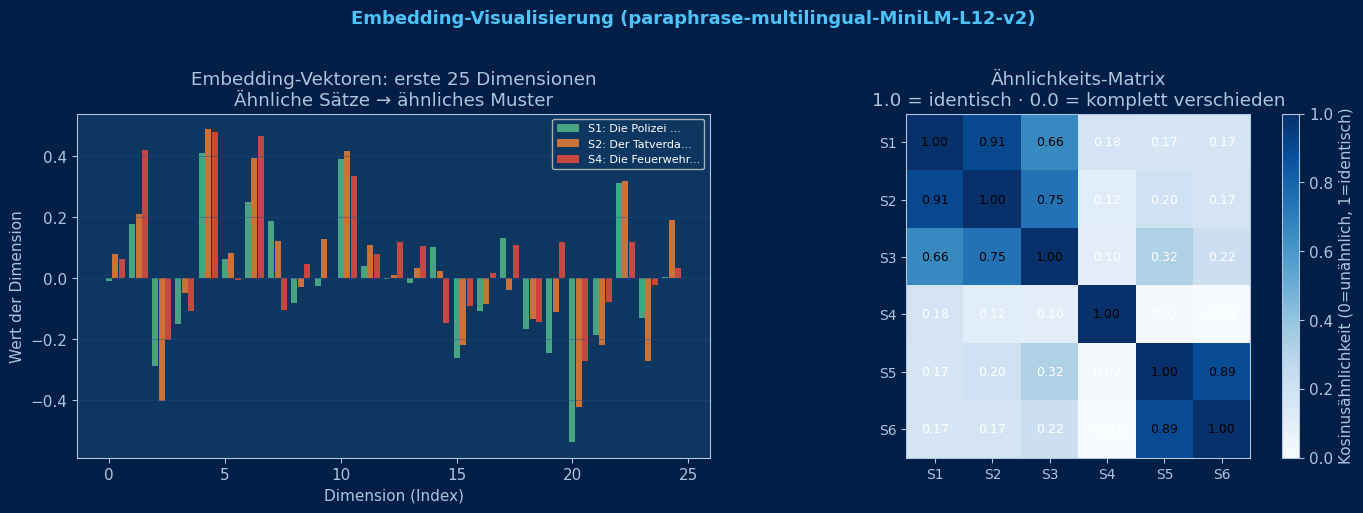

Beobachtung: S1+S2 und S5+S6 zeigen hohe Ähnlichkeit (Synonyme).
S1+S4 (Polizei / Feuerwehr) deutlich niedrig.


In [6]:
# ── Visualisierung: Vektoren + Ähnlichkeits-Matrix ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Embedding-Visualisierung (paraphrase-multilingual-MiniLM-L12-v2)',
             color=C['ice'], fontsize=13, fontweight='bold', y=1.02)

# ── Links: Erste 25 Dimensionen von 3 Sätzen ─────────────────────────────────
n_dims = 25
x_f = np.arange(n_dims)
farben3 = [C['green'], C['orange'], C['red']]
kurztexte = ['S1: Die Polizei ...', 'S2: Der Tatverda...', 'S4: Die Feuerwehr...']

for i, (farbe, kurz) in enumerate(zip(farben3, kurztexte)):
    axes[0].bar(x_f + i*0.28, emb[i, :n_dims], 0.26,
                label=kurz, color=farbe, alpha=0.85)

axes[0].set_title('Embedding-Vektoren: erste 25 Dimensionen\n'
                  'Ähnliche Sätze → ähnliches Muster',
                  color=C['lgray'])
axes[0].set_xlabel('Dimension (Index)')
axes[0].set_ylabel('Wert der Dimension')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, axis='y')

# ── Rechts: Ähnlichkeits-Matrix (Heatmap) ────────────────────────────────────
im = axes[1].imshow(sim, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[1], label='Kosinusähnlichkeit (0=unähnlich, 1=identisch)')
kzn = [f'S{i+1}' for i in range(len(saetze))]
axes[1].set_xticks(range(len(saetze))); axes[1].set_xticklabels(kzn, fontsize=10)
axes[1].set_yticks(range(len(saetze))); axes[1].set_yticklabels(kzn, fontsize=10)
axes[1].set_title('Ähnlichkeits-Matrix\n1.0 = identisch · 0.0 = komplett verschieden',
                  color=C['lgray'])
for i in range(len(saetze)):
    for j in range(len(saetze)):
        farbe_text = 'black' if sim[i,j] > 0.5 else 'white'
        axes[1].text(j, i, f'{sim[i,j]:.2f}',
                     ha='center', va='center', fontsize=9, color=farbe_text)
plt.tight_layout()
plt.show()
print('Beobachtung: S1+S2 und S5+S6 zeigen hohe Ähnlichkeit (Synonyme).')
print('S1+S4 (Polizei / Feuerwehr) deutlich niedrig.')


---

## Teil 3 – Ähnlichkeits-Heatmap: 20 Polizei- und Tech-Begriffe

### Was zeigt diese Grafik?

Wir berechnen die Ähnlichkeit zwischen 20 Schlüsselbegriffen aus dem Polizei- und  
Technikbereich. Die Heatmap macht semantische Cluster sichtbar:

- **Grün (hohe Ähnlichkeit):** Begriffe sind semantisch verwandt
- **Rot (niedrige Ähnlichkeit):** Begriffe haben wenig gemeinsam

> 💡 Mit Sentence-Transformers erkennt das Modell echte semantische Verwandtschaft –
> auch wenn die Wörter sich nicht ähneln (z.B. `Verdächtiger` ↔ `Beschuldigter`).  
> TF-IDF erkennt nur Wortüberlappungen.


Berechne Embeddings für 20 Begriffe...


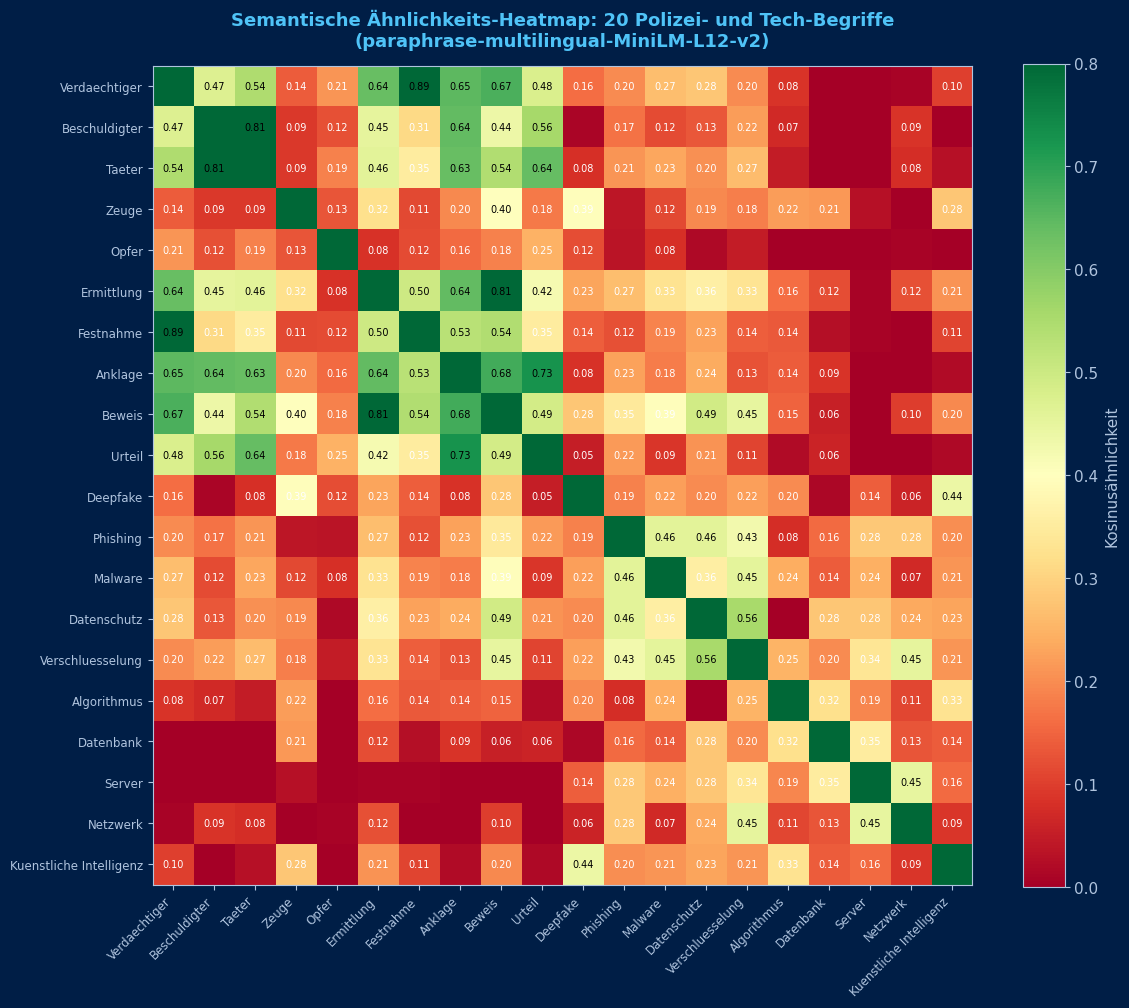

Top-5 ähnlichste Begriffspaare:
  0.887: Verdaechtiger <──> Festnahme
  0.810: Beschuldigter <──> Taeter
  0.809: Ermittlung <──> Beweis
  0.726: Anklage <──> Urteil
  0.678: Anklage <──> Beweis

Erwartete Cluster:
  Personen: Verdaechtiger ↔ Beschuldigter ↔ Taeter (alle im Strafverfahren)
  Cyber:    Phishing ↔ Malware ↔ Deepfake (alle Angriffsmethoden)
  Recht:    Anklage ↔ Urteil ↔ Beweis (alle Prozess-Elemente)


In [7]:
# ── Ähnlichkeits-Heatmap: 20 Polizei- und Tech-Begriffe ─────────────────────
begriffe = [
    'Verdaechtiger','Beschuldigter','Taeter','Zeuge','Opfer',
    'Ermittlung','Festnahme','Anklage','Beweis','Urteil',
    'Deepfake','Phishing','Malware','Datenschutz','Verschluesselung',
    'Algorithmus','Datenbank','Server','Netzwerk','Kuenstliche Intelligenz',
]

# Kontext-Strings für bessere Einbettung kurzer Einzelwörter
kontext = [
    'verdaechtiger tatverdaechtiger polizei festnahme strafverfolgung person',
    'beschuldigter angeklagter taeter anklage strafverfolgung gericht',
    'taeter krimineller straftaeter verbrechen delikte schuldig',
    'zeuge aussage zeugenaussage befragung gericht sehen beobachten',
    'opfer geschaedigt schaden tathergang person betroffen verletzt',
    'ermittlung ermittler kriminalpolizei untersuchung recherche aufklaerung',
    'festnahme verhaftung verhaftet inhaftierung polizei einsatz',
    'anklage staatsanwalt anklageschrift strafanzeige verfahren',
    'beweis beweismittel spurensicherung forensik kriminalistik sicherung',
    'urteil verurteilung strafe gericht rechtsprechung spruch',
    'deepfake gefaelschte bilder video manipulation ki generiert',
    'phishing betrug email passwort identitaetsdiebstahl online',
    'malware schadsoftware virus trojaner ransomware schadprogramm',
    'datenschutz dsgvo persoenliche daten privatsphäre eu schutz',
    'verschluesselung kryptographie ssl tls sicherer kanal chiffrierung',
    'algorithmus berechnung computerprogramm code logik verfahren prozess',
    'datenbank speicher tabellen sql abfragen information strukturiert',
    'server rechner cloud infrastruktur hosting betrieb rechenzentrum',
    'netzwerk verbindung internet router protokoll kommunikation verbunden',
    'kuenstliche intelligenz maschinelles lernen deep learning ki modell',
]

print('Berechne Embeddings für 20 Begriffe...')
emb2 = MODEL.encode(kontext, show_progress_bar=False)
sim2 = cosine_similarity(emb2)

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_title('Semantische Ähnlichkeits-Heatmap: 20 Polizei- und Tech-Begriffe\n'
             '(paraphrase-multilingual-MiniLM-L12-v2)',
             color=C['ice'], fontweight='bold', fontsize=13, pad=14)
im = ax.imshow(sim2, cmap='RdYlGn', vmin=0, vmax=0.8)
plt.colorbar(im, ax=ax, label='Kosinusähnlichkeit')
ax.set_xticks(range(len(begriffe))); ax.set_xticklabels(begriffe, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(len(begriffe))); ax.set_yticklabels(begriffe, fontsize=8.5)
for i in range(len(begriffe)):
    for j in range(len(begriffe)):
        if i != j and sim2[i,j] > 0.05:
            farbe_text = 'black' if sim2[i,j] > 0.4 else 'white'
            ax.text(j, i, f'{sim2[i,j]:.2f}',
                    ha='center', va='center', fontsize=7, color=farbe_text)
plt.tight_layout(); plt.show()

paare2 = [(sim2[i,j], begriffe[i], begriffe[j])
          for i in range(len(begriffe))
          for j in range(i+1, len(begriffe))]
paare2.sort(reverse=True)
print('Top-5 ähnlichste Begriffspaare:')
for s, b1, b2 in paare2[:5]:
    print(f'  {s:.3f}: {b1} <──> {b2}')
print()
print('Erwartete Cluster:')
print('  Personen: Verdaechtiger ↔ Beschuldigter ↔ Taeter (alle im Strafverfahren)')
print('  Cyber:    Phishing ↔ Malware ↔ Deepfake (alle Angriffsmethoden)')
print('  Recht:    Anklage ↔ Urteil ↔ Beweis (alle Prozess-Elemente)')


---

## Teil 4 – t-SNE: Der semantische Raum in 2D sichtbar machen

### Was ist t-SNE?

Embedding-Vektoren haben 384 Dimensionen – wir können sie nicht direkt sehen.  
**t-SNE** (t-Distributed Stochastic Neighbor Embedding) reduziert sie auf 2D,  
sodass wir den semantischen Raum als Punktwolke sehen können.

> **Wichtig:** t-SNE verändert Abstände. Absolute Entfernungen sind nicht vergleichbar.  
> Aber: Was im Hochdimensionalen nahe beieinander liegt, liegt auch in 2D nahe.

### Was zeigt das Diagramm?

48 Begriffe aus 6 Domänen werden als Punkte gezeichnet.  
Wenn das Modell gut funktioniert, **clustern** gleichartige Begriffe zusammen –  
obwohl das Modell nie nach Kategorien sortiert wurde.

Das ist semantisches Verständnis: Bedeutung entsteht aus Kontext, nicht aus Regeln.


Berechne Embeddings für 48 Begriffe...
t-SNE Berechnung (ca. 10 Sekunden)...


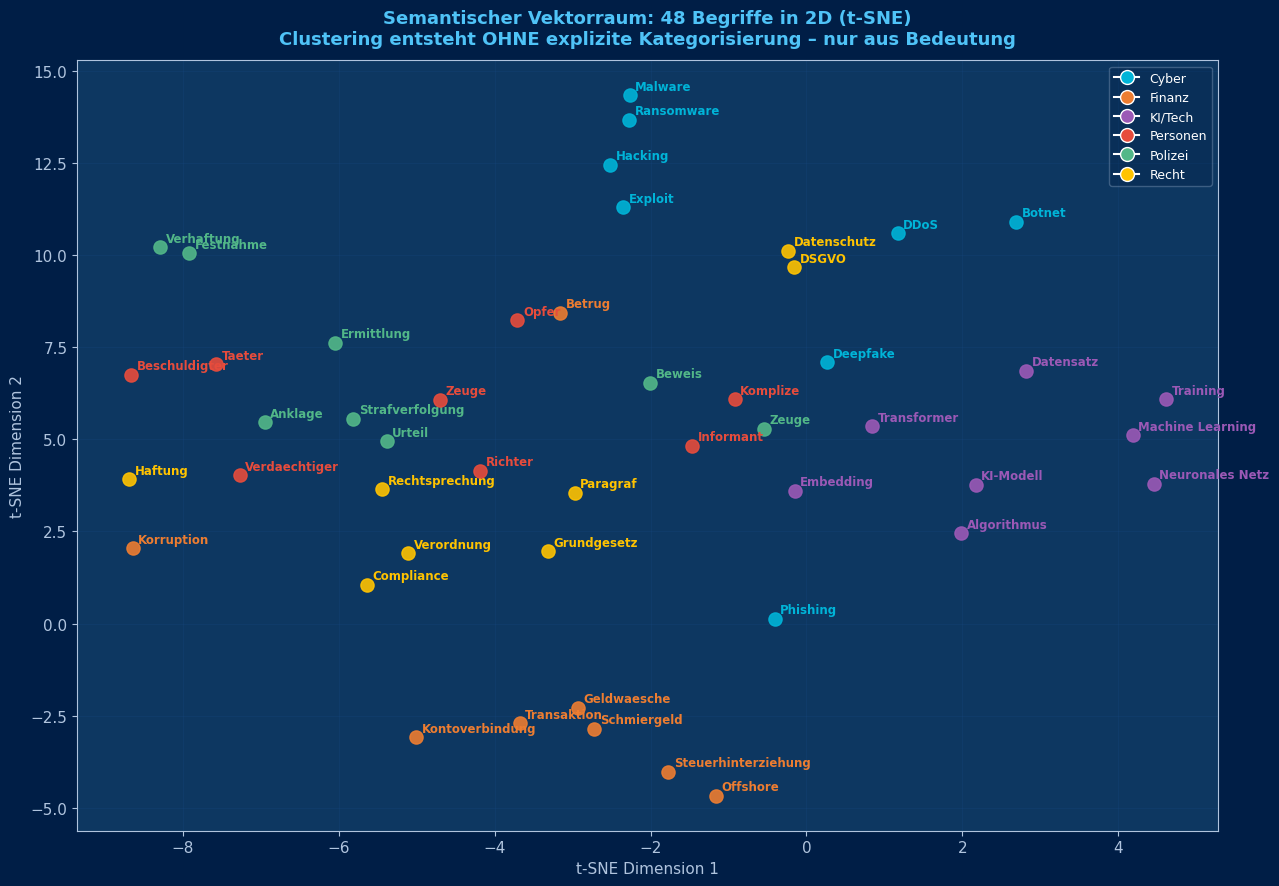

Gleiche Farben → gleiche Kategorie. Cluster = semantisches Verständnis.


In [8]:
# ── t-SNE: 48 Begriffe aus 6 Domänen in 2D ───────────────────────────────────
woerter_kat = [
    ('Festnahme','Polizei'),      ('Verhaftung','Polizei'),
    ('Ermittlung','Polizei'),     ('Strafverfolgung','Polizei'),
    ('Anklage','Polizei'),        ('Urteil','Polizei'),
    ('Beweis','Polizei'),         ('Zeuge','Polizei'),
    ('Deepfake','Cyber'),         ('Phishing','Cyber'),
    ('Ransomware','Cyber'),       ('Malware','Cyber'),
    ('Hacking','Cyber'),          ('Exploit','Cyber'),
    ('Botnet','Cyber'),           ('DDoS-Angriff','Cyber'),
    ('Algorithmus','KI/Tech'),    ('Neuronales Netz','KI/Tech'),
    ('Machine Learning','KI/Tech'),('Datensatz','KI/Tech'),
    ('Training','KI/Tech'),       ('Embedding','KI/Tech'),
    ('Transformer','KI/Tech'),    ('KI-Modell','KI/Tech'),
    ('Geldwaesche','Finanz'),     ('Betrug','Finanz'),
    ('Korruption','Finanz'),      ('Schmiergeld','Finanz'),
    ('Kontoverbindung','Finanz'), ('Transaktion','Finanz'),
    ('Offshore-Konto','Finanz'),  ('Steuerhinterziehung','Finanz'),
    ('DSGVO','Recht'),            ('Datenschutz','Recht'),
    ('Rechtsprechung','Recht'),   ('Verordnung','Recht'),
    ('Grundgesetz','Recht'),      ('Paragraf','Recht'),
    ('Compliance','Recht'),       ('Haftung','Recht'),
    ('Verdaechtiger','Personen'), ('Beschuldigter','Personen'),
    ('Taeter','Personen'),        ('Komplize','Personen'),
    ('Informant','Personen'),     ('Opfer','Personen'),
    ('Zeuge','Personen'),         ('Richter','Personen'),
]

kontext3 = [
    'festnahme verhaftung polizei sicherung','verhaftung festnahme beschuldigter',
    'ermittlung kriminalpolizei untersuchung','strafverfolgung anklaege gericht',
    'anklage staatsanwalt gericht recht','urteil verurteilung strafe gericht',
    'beweis beweismittel forensik spur','zeuge aussage gericht befragung',
    'deepfake gefaelschtes video bild ki','phishing betrug email passwort',
    'ransomware erpressung schadsoftware','malware virus schadsoftware angriff',
    'hacking einbruch sicherheitsluecke','exploit schwachstelle angriff',
    'botnet zombie netzwerk ddos','ddos netzwerk angriff denial service',
    'algorithmus code programm berechnung','neuronales netz deep learning schichten',
    'machine learning training modell','datensatz daten samples training',
    'training lernen optimierung gradient','embedding vektor semantisch',
    'transformer attention architektur gpt','ki modell algorithmus vorhersage',
    'geldwaesche transaktion verschleierung','betrug taeuschen schaden',
    'korruption bestechung amtsmissbrauch','schmiergeld bestechung zahlung',
    'kontoverbindung iban bank konto','transaktion ueberweisung zahlung bank',
    'offshore steuerparadies ausland','steuerhinterziehung finanzamt steuer',
    'dsgvo datenschutz verordnung eu','datenschutz daten privatsphäre schutz',
    'rechtsprechung recht gesetz gericht','verordnung gesetz regel vorschrift',
    'grundgesetz verfassung recht deutschland','paragraf gesetz strafgesetzbuch',
    'compliance regelkonformitaet vorschriften','haftung verantwortung schuld',
    'verdaechtiger tatverdaechtiger beschuldigter','beschuldigter angeklagter taeter',
    'taeter krimineller straftaeter','komplize mittaeter mitschuldiger',
    'informant spitzel verdeckt hinweis','opfer geschaedigt schaden person',
    'zeuge aussage befragung strafprozess','richter gericht urteil vorsitz',
]

print('Berechne Embeddings für 48 Begriffe...')
emb3 = MODEL.encode(kontext3, show_progress_bar=False)

# t-SNE: Hochdimensionale Vektoren auf 2D reduzieren
# perplexity ≈ typische Nachbarschaftsgröße (empfohlen: 5–50)
print('t-SNE Berechnung (ca. 10 Sekunden)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=12,
            max_iter=1500, learning_rate='auto', init='pca')
coords = tsne.fit_transform(emb3)

cat_list  = sorted(set(k for _,k in woerter_kat))
cat_farben= [C['teal'], C['orange'], C['purple'], C['red'], C['green'], C['gold']]
cat2c     = {k: f for k, f in zip(cat_list, cat_farben)}

fig, ax = plt.subplots(figsize=(13, 9))
ax.set_title('Semantischer Vektorraum: 48 Begriffe in 2D (t-SNE)\n'
             'Clustering entsteht OHNE explizite Kategorisierung – nur aus Bedeutung',
             color=C['ice'], fontsize=13, fontweight='bold', pad=12)

for i, (wort, kat) in enumerate(woerter_kat):
    col = cat2c[kat]
    ax.scatter(coords[i,0], coords[i,1], c=col, s=90, zorder=3, alpha=0.9)
    label = wort.replace('-Angriff','').replace('-Konto','')
    ax.annotate(label, (coords[i,0], coords[i,1]),
                fontsize=8.5, color=col, fontweight='bold',
                xytext=(4,4), textcoords='offset points')

from matplotlib.lines import Line2D
legende_punkte = [Line2D([0],[0], marker='o', color='w',
                         markerfacecolor=cat2c[c], markersize=10, label=c)
                  for c in cat_list]
ax.legend(handles=legende_punkte, loc='upper right',
          framealpha=0.3, facecolor=C['navy'], edgecolor=C['lgray'], fontsize=9)
ax.grid(True, alpha=0.2)
ax.set_xlabel('t-SNE Dimension 1', color=C['lgray'])
ax.set_ylabel('t-SNE Dimension 2', color=C['lgray'])
plt.tight_layout(); plt.show()
print('Gleiche Farben → gleiche Kategorie. Cluster = semantisches Verständnis.')


---

## 🔍 Exkurs: Drei verschiedene Dinge namens „Embedding"

> **Häufige Verwechslung:** Das Wort „Embedding" wird im KI-Bereich für  
> drei verschiedene Konzepte verwendet. Das führt zu Verwirrung.

---

### Die vollständige Pipeline – präzise

```
Ihr Text
  │
  ▼
┌─────────────────────────────────────────────────────┐
│  TOKENIZER  (z.B. BPE)                              │
│  → Kein neuronales Netz, nur Lookup-Tabelle         │
│  → „Polizei" → [45123, 6782]  (Token-IDs)          │
│  → Deterministisch, immer gleich                    │
└─────────────────────────────────────────────────────┘
  │  Token-IDs  [45123, 6782, ...]
  ▼
┌─────────────────────────────────────────────────────┐
│  EMBEDDING-SCHICHT  (Teil des LLM, erste Schicht)   │
│  → Lookup-Matrix: jede Token-ID → dichter Vektor   │
│  → [45123] → [0.23, -0.87, 0.44, ...]  (z.B. 4096 Werte)  │
│  → Wurde beim Training gelernt                      │
└─────────────────────────────────────────────────────┘
  │  Vektoren
  ▼
┌─────────────────────────────────────────────────────┐
│  TRANSFORMER-SCHICHTEN  (Attention + FFN)           │
│  → Kontext verarbeiten, Beziehungen lernen          │
│  → Reines Rechnen mit Zahlen                        │
└─────────────────────────────────────────────────────┘
  │  Ausgabe-Vektor
  ▼
┌─────────────────────────────────────────────────────┐
│  OUTPUT-SCHICHT  (de-embedding / lm_head)           │
│  → Vektor → Wahrscheinlichkeiten über alle Token-IDs│
│  → Token-ID mit höchster W'keit → Ausgabe-Token     │
└─────────────────────────────────────────────────────┘
  │  Token-ID → Tokenizer (rückwärts)
  ▼
Ausgabe-Text
```

---

### Die drei Bedeutungen von „Embedding" im Vergleich

| Begriff | Was es ist | Wer nutzt es | Im Notebook |
|---|---|---|---|
| **1. Tokenizer** | Text → Token-IDs · reiner Lookup, kein Netz | Vorschritt vor jedem LLM | Teil 1 (BPE-Demo) |
| **2. Embedding-Schicht (LLM-intern)** | Token-ID → dichter Vektor · erste Schicht des LLM · wird mittrainiert | Teil des LLM selbst | Nicht direkt sichtbar |
| **3. Sentence-Embedding-Modell** | Satz → fixer Vektor · eigenständiges Modell · für Ähnlichkeitssuche | Separat, z.B. für RAG | Teil 2–6 (`MODEL.encode()`) |

> **Der entscheidende Unterschied zwischen 2 und 3:**  
> Die Embedding-**Schicht** im LLM mappt *einzelne Token-IDs* auf Vektoren  
> und ist untrennbarer Teil des LLMs.  
> Das Sentence-Embedding-**Modell** mappt *ganze Sätze* auf einen einzigen Vektor  
> und ist ein eigenständiges, separates Netz.

---

### Präzise Formulierung

> Der **Tokenizer** wandelt Text in Token-IDs um – er ist ein einfacher  
> deterministischer Algorithmus (keine KI, keine Gewichte).  
>
> Das **LLM** empfängt nur Token-IDs, wandelt sie intern in Vektoren um  
> (Embedding-Schicht) und rechnet damit – es sieht nie rohen Text.  
>
> Das **Sentence-Embedding-Modell** (wie in diesem Notebook) ist ein  
> *separates* Netz für Ähnlichkeitssuche – nicht Teil des LLMs.


---

## Teil 5 – LLM als Wahrscheinlichkeitsmaschine

### Das wichtigste Konzept: LLMs sagen das nächste Token voraus

> **LLMs haben kein Gedächtnis. Sie kennen keine Fakten.**  
> Sie berechnen bei jedem Schritt: „Was ist das wahrscheinlichste nächste Token?"

Das klingt simpel – aber aus Milliarden Texten gelernt entstehen scheinbar  
intelligente Antworten. Dieses Phänomen heißt **Emergenz**.

### Bigram-Simulation: Das vereinfachte LLM

Wir simulieren dieses Prinzip mit einem **Bigram-Modell**:
- Zähle in einem Corpus: Welches Wort folgt auf welches?
- Bei der Eingabe `„der"` → Welches Wort kam im Corpus am häufigsten danach?

```
Corpus: „der Verdächtige floh" · „der Täter nutzte" · „der Zeuge sah"
           ↓
Nach „der": Verdächtige 33% · Täter 33% · Zeuge 33%
```

Das echte GPT-4 tut dasselbe – nur mit:
- **100.000 Token** im Vokabular (statt unserer ~50 Wörter)
- **175 Milliarden Parameter** (statt unserer Zählungen)
- **128.000 Token Kontext** (statt unserer 12 Sätze)

### Warum halluzinieren LLMs?

> **Halluzination** = das Modell erfindet fakten, weil es das statistisch  
> plausibelste Token generiert – auch wenn es faktisch falsch ist.

Wenn nach `„Aktenzeichen"` im Trainingskorpus immer Nummern stehen,  
generiert das Modell eine plausibel klingende Nummer – auch eine erfundene.


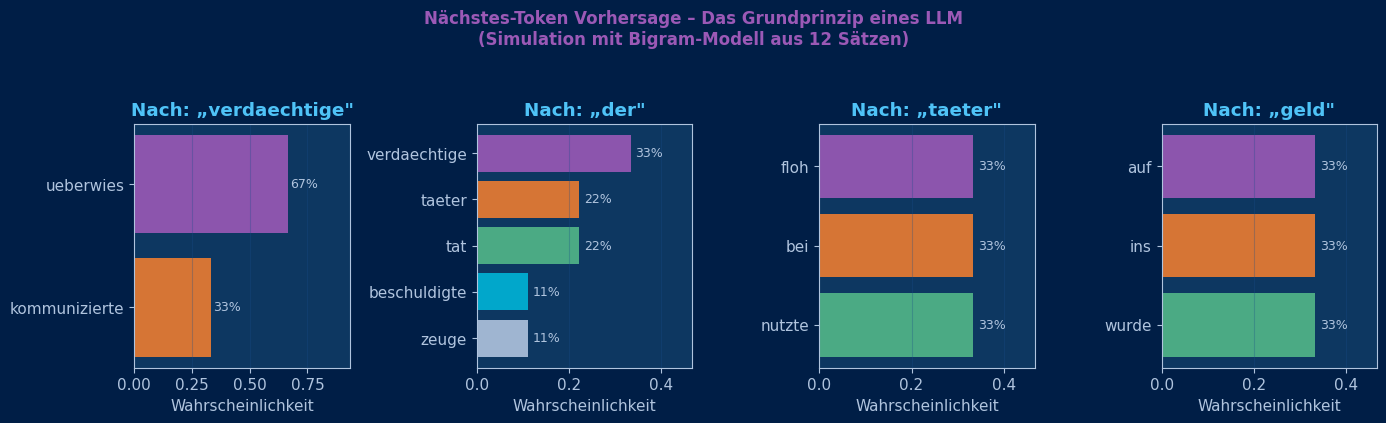

Das echte GPT-4 tut DASSELBE – nur mit:
  100.000 Token Vokabular  |  175 Mrd. Parameter  |  128k Token Kontext

→ „Emergente Intelligenz" aus reiner Wahrscheinlichkeitsoptimierung

───────────────────────────────────────────────────────
HALLUZINATIONS-PRINZIP: Warum erfindet ein LLM Fakten?
───────────────────────────────────────────────────────

Wenn das Modell nach einem seltenen Begriff gefragt wird,
der nicht im Corpus vorkommt → es interpoliert/erfindet:

  Wort „paragraf": ❌ Nicht im Corpus
  → Ein echtes LLM würde hier statistisch plausiblen Text erfinden
  → Das klingt überzeugend, kann aber faktisch falsch sein

  Wort „aktenzeichen": ❌ Nicht im Corpus
  → Ein echtes LLM würde hier statistisch plausiblen Text erfinden
  → Das klingt überzeugend, kann aber faktisch falsch sein

  Wort „bundeskriminalamt": ❌ Nicht im Corpus
  → Ein echtes LLM würde hier statistisch plausiblen Text erfinden
  → Das klingt überzeugend, kann aber faktisch falsch sein

Fazit: LLMs halluzinieren NIC

In [9]:
# ── Bigram-Simulation: Das Prinzip eines LLMs ────────────────────────────────
# Corpus = kleine Textsammlung aus dem Polizeikontext
# Das Modell "lernt" nur aus diesem Corpus – keine externen Kenntnisse

corpus = [
    'der verdaechtige ueberwies das geld auf ein auslaendisches konto',
    'der beschuldigte nutzte verschluesselte kommunikation zur tatplanung',
    'der taeter floh nach der tat in richtung norden',
    'die polizei verhaftete den verdaechtigen am tatort',
    'der zeuge beobachtete den taeter bei der tat',
    'das gericht verurteilte den beschuldigten zu drei jahren haft',
    'der verdaechtige ueberwies das geld ins ausland',
    'die ermittler sicherten digitale beweise am tatort',
    'der taeter nutzte einen deepfake zur taeuschung',
    'das geld wurde auf mehrere konten verteilt',
    'der verdaechtige kommunizierte ueber verschluesselte kanaele',
    'die festnahme erfolgte nach intensiver ermittlungsarbeit',
]

# ── Bigram-Tabelle aufbauen ───────────────────────────────────────────────────
# bigrams = {(wort1, wort2): häufigkeit}
# Bedeutet: Wort2 folgte Wort1 wie oft im Corpus?
bigrams = Counter()
for satz in corpus:
    woerter = satz.split()                  # Satz → Wortliste
    for i in range(len(woerter) - 1):       # Alle benachbarten Wortpaare
        bigrams[(woerter[i], woerter[i+1])] += 1   # Paar zählen

def vorhersage_naechstes(wort, top_n=5):
    """
    Gibt die wahrscheinlichsten Folgewörter für 'wort' zurück.
    Basiert auf Häufigkeiten im Corpus (Bigram-Modell).
    """
    # Alle Bigrams finden, die mit 'wort' beginnen
    kandidaten = {k[1]: v for k, v in bigrams.items() if k[0] == wort}
    if not kandidaten:
        return []   # Wort nicht im Corpus
    gesamt = sum(kandidaten.values())
    # Wahrscheinlichkeiten berechnen (Häufigkeit / Gesamthäufigkeit)
    return sorted(
        [(w, cnt/gesamt) for w, cnt in kandidaten.items()],
        key=lambda x: -x[1]    # Absteigende Sortierung nach Wahrscheinlichkeit
    )[:top_n]

# ── Balkendiagramm: Nächstes Token für 4 Eingabewörter ───────────────────────
testwoerter = ['verdaechtige', 'der', 'taeter', 'geld']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Nächstes-Token Vorhersage – Das Grundprinzip eines LLM\n'
             '(Simulation mit Bigram-Modell aus 12 Sätzen)',
             color=C['purple'], fontsize=12, fontweight='bold', y=1.05)

farben4 = [C['purple'], C['orange'], C['green'], C['teal'], C['lgray']]

for ax, wort in zip(axes, testwoerter):
    vorhers = vorhersage_naechstes(wort)
    if vorhers:
        labels = [v[0] for v in vorhers]
        probs  = [v[1] for v in vorhers]
        # Horizontales Balkendiagramm (umgekehrte Reihenfolge für bessere Lesbarkeit)
        ax.barh(labels[::-1], probs[::-1],
                color=farben4[:len(labels)][::-1], alpha=0.9)
        # Prozentzahlen hinter den Balken
        for i, (lbl, prob) in enumerate(zip(labels[::-1], probs[::-1])):
            ax.text(prob + 0.01, i, f'{prob:.0%}',
                    va='center', fontsize=9, color=C['lgray'])
        ax.set_title(f'Nach: „{wort}"', color=C['ice'], fontweight='bold')
        ax.set_xlabel('Wahrscheinlichkeit')
        ax.set_xlim(0, max(probs) * 1.4)
        ax.grid(True, axis='x', alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'„{wort}"\nnicht\nim Corpus',
                ha='center', va='center', transform=ax.transAxes, color=C['lgray'])

plt.tight_layout()
plt.show()

print('Das echte GPT-4 tut DASSELBE – nur mit:')
print('  100.000 Token Vokabular  |  175 Mrd. Parameter  |  128k Token Kontext')
print()
print('→ „Emergente Intelligenz" aus reiner Wahrscheinlichkeitsoptimierung')

# ── Halluzinations-Demo ───────────────────────────────────────────────────────
print()
print('─' * 55)
print('HALLUZINATIONS-PRINZIP: Warum erfindet ein LLM Fakten?')
print('─' * 55)
print()
print('Wenn das Modell nach einem seltenen Begriff gefragt wird,')
print('der nicht im Corpus vorkommt → es interpoliert/erfindet:')
print()

seltene = ['paragraf', 'aktenzeichen', 'bundeskriminalamt']
for wort in seltene:
    vorhers = vorhersage_naechstes(wort)
    if not vorhers:
        print(f'  Wort „{wort}": ❌ Nicht im Corpus')
        print(f'  → Ein echtes LLM würde hier statistisch plausiblen Text erfinden')
        print(f'  → Das klingt überzeugend, kann aber faktisch falsch sein')
        print()
    else:
        print(f'  Wort „{wort}": im Corpus → {vorhers[:2]}')

print('Fazit: LLMs halluzinieren NICHT aus Bosheit,')
print('sondern weil sie immer das statistisch plausibelste Token generieren.')


---

## Teil 6 – 🚔 Challenge: Semantische Ähnlichkeitssuche

### Szenario: Beschlagnahmter Chat-Verlauf

Ein verschlüsselter Chat-Verlauf wurde sichergestellt. Die Ermittler wollen  
gezielt nach verdächtigen Nachrichten suchen – aber ohne Stichwort-Suche,  
die leicht durch Codes umgangen wird.

**Lösung: Semantische Suche**

Statt Stichwörter zu suchen, kodieren wir die Suchanfrage als Embedding-Vektor  
und suchen nach den Chat-Nachrichten mit dem ähnlichsten Vektor.

```
Suchanfrage: „Geldtransfer Zahlung Überweisung"
    ↓
Embedding-Vektor der Suchanfrage
    ↓
Kosinusähnlichkeit mit allen Chat-Nachrichten
    ↓
Treffer: „Überweise den Betrag auf das bekannte Konto" (hohe Ähnlichkeit)
```

### Das ist das RAG-Grundprinzip

> **RAG** = Retrieval-Augmented Generation  
> In Session S2.4 (Notebook-07) vertiefen wir das:  
> Eigene Dokumente in eine Vektordatenbank laden → KI beantwortet Fragen daraus.


In [10]:
# ── Semantische Suche im beschlagnahmten Chat-Verlauf ─────────────────────────
chat = [
    'Treffen wir uns heute Nacht am alten Lagerhaus.',
    'Die Ware kommt morgen frueh um drei Uhr an.',
    'Ueberweise den Betrag auf das bekannte Konto.',
    'Ich habe das Paket wie besprochen deponiert.',
    'Bitte verwende nur den sicheren Kanal fuer Nachrichten.',
    'Der Preis wurde auf fuenfzehn tausend erhoeht.',
    'Wir sollten die Lieferung verschieben zu viel Aufmerksamkeit.',
    'Das Geld wurde erfolgreich transferiert Bestaetigung folgt.',
    'Bringe die Dokumente beim naechsten Treffen mit.',
    'Alles laeuft nach Plan halte dich bereit.',
]
suchanfragen = [
    'Geldtransfer Zahlung Ueberweisung Konto',
    'Geheimtreffen Verabredung Treffpunkt Ort',
    'Vorsicht Verschiebung Risiko vermeiden Aufmerksamkeit',
]

# Alle Texte zusammen einbetten (einheitlicher Vektorraum)
print('Berechne Embeddings für Chat und Suchanfragen...')
alle_texte  = chat + suchanfragen
alle_emb    = MODEL.encode(alle_texte, show_progress_bar=False)
chat_emb    = alle_emb[:len(chat)]
anfragen_emb = alle_emb[len(chat):]

print()
print('SEMANTISCHE SUCHANALYSE – Beschlagnahmter Chat-Verlauf')
print('=' * 65)

for anfrage, q_emb in zip(suchanfragen, anfragen_emb):
    scores = cosine_similarity([q_emb], chat_emb)[0]
    ranked = sorted(enumerate(scores), key=lambda x: -x[1])
    print(f'\nSuchanfrage: „{anfrage}"')
    print(f'  {"Rang":<5} {"Score":<8} {"Nachricht":<52} {"Status"}')
    print(f'  {"-"*5} {"-"*7} {"-"*52} {"-"*15}')
    for rang, (idx, score) in enumerate(ranked[:5], 1):
        if score > 0.45:
            status = '🔴 TREFFER'
        elif score > 0.30:
            status = '🟡 Möglicher Treffer'
        else:
            status = '⚪ Kein Treffer'
        print(f'  {rang:<5} {score:.3f}   {chat[idx][:50]:<52} {status}')

print()
print('─' * 65)
print('Mit sentence-transformers: semantische Synonyme werden erkannt.')
print('Auch Umschreibungen und Codes finden passende Nachrichten.')


Berechne Embeddings für Chat und Suchanfragen...

SEMANTISCHE SUCHANALYSE – Beschlagnahmter Chat-Verlauf

Suchanfrage: „Geldtransfer Zahlung Ueberweisung Konto"
  Rang  Score    Nachricht                                            Status
  ----- ------- ---------------------------------------------------- ---------------
  1     0.682   Das Geld wurde erfolgreich transferiert Bestaetigu   🔴 TREFFER
  2     0.597   Ueberweise den Betrag auf das bekannte Konto.        🔴 TREFFER
  3     0.325   Der Preis wurde auf fuenfzehn tausend erhoeht.       🟡 Möglicher Treffer
  4     0.265   Bringe die Dokumente beim naechsten Treffen mit.     ⚪ Kein Treffer
  5     0.225   Ich habe das Paket wie besprochen deponiert.         ⚪ Kein Treffer

Suchanfrage: „Geheimtreffen Verabredung Treffpunkt Ort"
  Rang  Score    Nachricht                                            Status
  ----- ------- ---------------------------------------------------- ---------------
  1     0.525   Bringe die Dokumente beim n

### Visualisierung der Suchergebnisse

Jeder Balken zeigt die Ähnlichkeit einer Chat-Nachricht zur Suchanfrage.  
Rote Balken = hoher Score = mögliche Treffer.


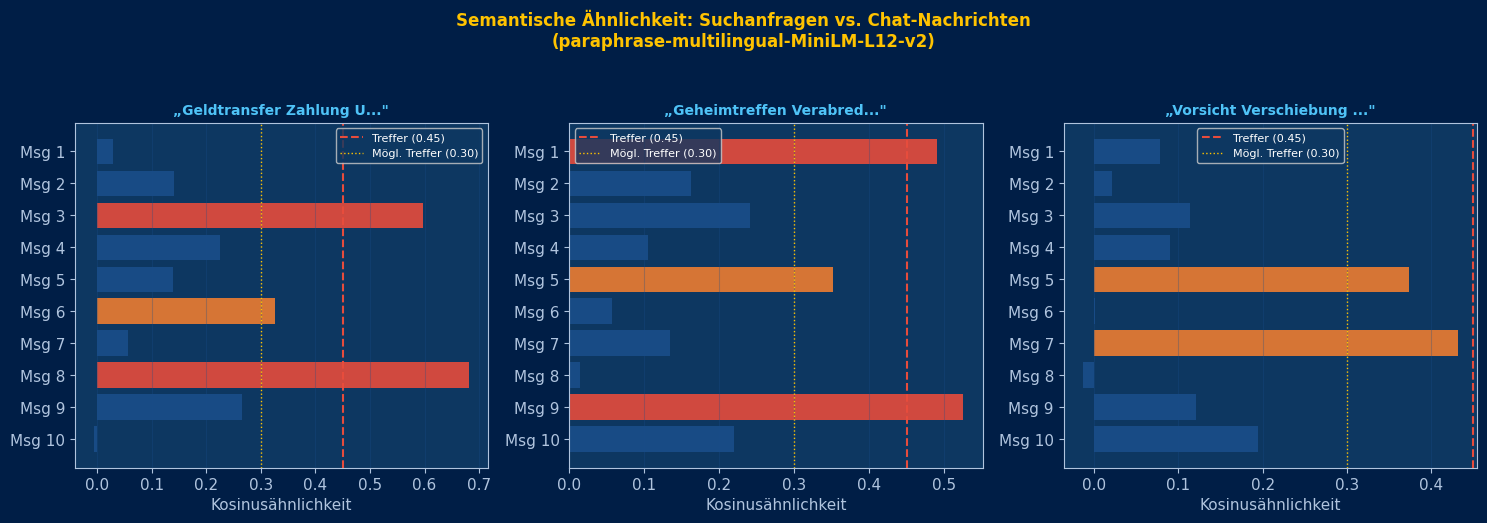


RAG-GRUNDPRINZIP:
  1. Dokumente in Embeddings umwandeln → Vektordatenbank
  2. Suchanfrage als Embedding kodieren
  3. Ähnlichste Treffer finden
  4. Treffer + Frage ans LLM → Antwort aus echten Dokumenten
  → Deutlich weniger Halluzinationen!

  In S2.4 (NB-07): ChromaDB + Ollama = vollständiges RAG-System


In [11]:
# ── Visualisierung der semantischen Suche ────────────────────────────────────
scores_alle = []
for q_emb in anfragen_emb:
    scores_alle.append(cosine_similarity([q_emb], chat_emb)[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Semantische Ähnlichkeit: Suchanfragen vs. Chat-Nachrichten\n'
             '(paraphrase-multilingual-MiniLM-L12-v2)',
             color=C['gold'], fontsize=12, fontweight='bold', y=1.04)

for ax, anfrage, scores in zip(axes, suchanfragen, scores_alle):
    labels = [f'Msg {i+1}' for i in range(len(chat))]
    farben_bars = [
        C['red']    if s > 0.45 else
        C['orange'] if s > 0.30 else
        C['blue2']
        for s in scores
    ]
    ax.barh(labels[::-1], scores[::-1], color=farben_bars[::-1], alpha=0.9)
    ax.axvline(0.45, color=C['red'],  lw=1.5, ls='--', label='Treffer (0.45)')
    ax.axvline(0.30, color=C['gold'], lw=1.0, ls=':',  label='Mögl. Treffer (0.30)')
    titel = anfrage[:22] + '...' if len(anfrage) > 22 else anfrage
    ax.set_title(f'„{titel}"', color=C['ice'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Kosinusähnlichkeit')
    ax.legend(fontsize=8)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

print()
print('RAG-GRUNDPRINZIP:')
print('  1. Dokumente in Embeddings umwandeln → Vektordatenbank')
print('  2. Suchanfrage als Embedding kodieren')
print('  3. Ähnlichste Treffer finden')
print('  4. Treffer + Frage ans LLM → Antwort aus echten Dokumenten')
print('  → Deutlich weniger Halluzinationen!')
print()
print('  In S2.4 (NB-07): ChromaDB + Ollama = vollständiges RAG-System')


---

## Zusammenfassung – Was haben wir gelernt?

| Konzept | Technik | Kernaussage |
|---------|---------|-------------|
| **Tokenisierung** | BPE-Simulation | LLMs lesen keine Wörter – sie rechnen mit Zahlen-IDs |
| **DE vs. EN** | Tokenanzahl-Vergleich | Deutsch braucht ~1.3× mehr Tokens → höhere Kosten |
| **Embeddings** | TF-IDF / Sentence-Transformers | Ähnliche Bedeutung → ähnlicher Vektor im Raum |
| **Ähnlichkeit** | Kosinusähnlichkeit | Winkel zwischen Vektoren messen statt Wörter zählen |
| **Heatmap** | 20 Polizei-Begriffe | Semantische Cluster ohne explizite Kategorisierung |
| **t-SNE** | 48 Begriffe in 2D | Bedeutungsraum sichtbar machen |
| **Token-Vorhersage** | Bigram-Simulation | Das Grundprinzip jedes LLMs |
| **Halluzination** | Fehlende Corpus-Einträge | LLMs erfinden → Fakten immer prüfen! |
| **Semantische Suche** | Embedding-Ähnlichkeit | Grundlage von RAG (S2.4) |

---

### Die drei wichtigsten Erkenntnisse

> **1. LLM ≠ Datenbank.** Kein Gedächtnis, keine Fakten – nur Wahrscheinlichkeit.  
> Jede Aussage eines LLMs muss mit echten Quellen verifiziert werden.

> **2. Embeddings sind der Schlüssel zur semantischen Suche.**  
> `paraphrase-multilingual-MiniLM-L12-v2` versteht Bedeutung – nicht nur Wörter.  
> Das ermöglicht Suche die Synonyme, Umschreibungen und Tarnbegriffe erkennt.

---

### Ausblick: Nächste Sessions

| Session | Inhalt | Bezug |
|---|---|---|
| **S2.3** | Prompt Engineering | LLM-Verhalten durch Prompts steuern |
| **S2.4** | RAG mit ChromaDB + Ollama | Semantische Suche auf eigenen Dokumenten |
| **S2.5** | FindusGPT im Einsatz | Praxis-Challenge mit realem System |

---

**KI Advanced · IA1017000 · HfPolBW · Marc Brandt**
